#### Load Required Libraries

In [1]:
import pandas as pd
import numpy as np
import glob
import os
import joblib as jl

#### Load Models

In [2]:
rf = jl.load('/home/kali/Documents/IDS-Project/models/random_forest_best.pkl')
xgb = jl.load('/home/kali/Documents/IDS-Project/models/xgboost_best.pkl')
encoder = jl.load('/home/kali/Documents/IDS-Project/models/label_encoder.pkl')
scaler = jl.load('/home/kali/Documents/IDS-Project/models/scaler.pkl')

#### Load CSV Files and Merging

In [3]:
path = "/home/kali/Documents/IDS-Project/dataset/CIC-IDS-2018"

csv_files = glob.glob(os.path.join(path,"*.csv"))

print(csv_files)

features = list(rf.feature_names_in_)+['Label']
print(features)


['/home/kali/Documents/IDS-Project/dataset/CIC-IDS-2018/03-02-2018.csv', '/home/kali/Documents/IDS-Project/dataset/CIC-IDS-2018/02-20-2018.csv', '/home/kali/Documents/IDS-Project/dataset/CIC-IDS-2018/02-16-2018.csv', '/home/kali/Documents/IDS-Project/dataset/CIC-IDS-2018/02-14-2018.csv', '/home/kali/Documents/IDS-Project/dataset/CIC-IDS-2018/02-28-2018.csv', '/home/kali/Documents/IDS-Project/dataset/CIC-IDS-2018/03-01-2018.csv', '/home/kali/Documents/IDS-Project/dataset/CIC-IDS-2018/02-15-2018.csv', '/home/kali/Documents/IDS-Project/dataset/CIC-IDS-2018/02-22-2018.csv', '/home/kali/Documents/IDS-Project/dataset/CIC-IDS-2018/02-23-2018.csv', '/home/kali/Documents/IDS-Project/dataset/CIC-IDS-2018/02-21-2018.csv']
['Destination Port', 'Flow Duration', 'Total Fwd Packets', 'Total Length of Fwd Packets', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Bwd Packet Length Max', 'Bwd Packet Length Min', 'Flow Bytes/s', 'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT St

In [4]:
df = pd.read_csv(csv_files[0], nrows=0)

print(df.columns.tolist())

['Dst Port', 'Protocol', 'Timestamp', 'Flow Duration', 'Tot Fwd Pkts', 'Tot Bwd Pkts', 'TotLen Fwd Pkts', 'TotLen Bwd Pkts', 'Fwd Pkt Len Max', 'Fwd Pkt Len Min', 'Fwd Pkt Len Mean', 'Fwd Pkt Len Std', 'Bwd Pkt Len Max', 'Bwd Pkt Len Min', 'Bwd Pkt Len Mean', 'Bwd Pkt Len Std', 'Flow Byts/s', 'Flow Pkts/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Tot', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Tot', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Len', 'Bwd Header Len', 'Fwd Pkts/s', 'Bwd Pkts/s', 'Pkt Len Min', 'Pkt Len Max', 'Pkt Len Mean', 'Pkt Len Std', 'Pkt Len Var', 'FIN Flag Cnt', 'SYN Flag Cnt', 'RST Flag Cnt', 'PSH Flag Cnt', 'ACK Flag Cnt', 'URG Flag Cnt', 'CWE Flag Count', 'ECE Flag Cnt', 'Down/Up Ratio', 'Pkt Size Avg', 'Fwd Seg Size Avg', 'Bwd Seg Size Avg', 'Fwd Byts/b Avg', 'Fwd Pkts/b Avg', 'Fwd Blk Rate Avg', 'Bwd By

In [5]:
rename_dict = {
    "Dst Port": "Destination Port",
    "Tot Fwd Pkts": "Total Fwd Packets",
    "TotLen Fwd Pkts": "Total Length of Fwd Packets",

    "Fwd Pkt Len Max": "Fwd Packet Length Max",
    "Fwd Pkt Len Min": "Fwd Packet Length Min",
    "Fwd Pkt Len Mean": "Fwd Packet Length Mean",

    "Bwd Pkt Len Max": "Bwd Packet Length Max",
    "Bwd Pkt Len Min": "Bwd Packet Length Min",

    "Flow Byts/s": "Flow Bytes/s",
    "Flow Pkts/s": "Flow Packets/s",

    "Fwd IAT Tot": "Fwd IAT Total",
    "Bwd IAT Tot": "Bwd IAT Total",

    "Fwd Pkts/s": "Fwd Packets/s",
    "Bwd Pkts/s": "Bwd Packets/s",

    "Fwd Header Len": "Fwd Header Length",
    "Bwd Header Len": "Bwd Header Length",

    "Pkt Len Min": "Min Packet Length",

    "FIN Flag Cnt": "FIN Flag Count",
    "RST Flag Cnt": "RST Flag Count",
    "PSH Flag Cnt": "PSH Flag Count",
    "ACK Flag Cnt": "ACK Flag Count",
    "URG Flag Cnt": "URG Flag Count",

    "Init Fwd Win Byts": "Init_Win_bytes_forward",
    "Init Bwd Win Byts": "Init_Win_bytes_backward",

    "Fwd Act Data Pkts": "act_data_pkt_fwd",
    "Fwd Seg Size Min": "min_seg_size_forward",
}

In [6]:
dfs = []

for file in csv_files:
    df = pd.read_csv(file, low_memory=False)

    # Rename columns
    df.rename(columns=rename_dict, inplace=True)

    # Keep only the columns used by the model
    df = df[features]

    dfs.append(df)

df = pd.concat(dfs, ignore_index=True)

print(df.shape)

(16233002, 40)


In [7]:
missing = set(features) - set(df.columns)

print("Missing columns:", missing)

Missing columns: set()


#### Clean Data

In [8]:
df = df[df['Label']!='Label']

In [9]:
label_map = {
    "Benign": "BENIGN",

    "DoS attacks-Hulk": "DoS Hulk",
    "DoS attacks-GoldenEye": "DoS GoldenEye",
    "DoS attacks-Slowloris": "DoS slowloris",
    "DoS attacks-SlowHTTPTest": "DoS Slowhttptest",

    "DDoS attacks-LOIC-HTTP": "DDoS",
    "DDOS attack-HOIC": "DDoS",
    "DDOS attack-LOIC-UDP": "DDoS",

    "Bot": "Bot",
    "FTP-BruteForce": "FTP-Patator",
    "SSH-Bruteforce": "SSH-Patator",
    "Infilteration": "Infiltration",

    # IMPORTANT: use the replacement character exactly as stored
    'Brute Force -Web': "Web Attack � Brute Force",
    'Brute Force -XSS': "Web Attack � XSS",
    "SQL Injection": "Web Attack � Sql Injection",
}

In [10]:
df = df[df["Label"] != "Label"]
df = df.dropna(subset=["Label"])

df["Label"] = df["Label"].replace(label_map)

unknown = set(df["Label"].unique()) - set(encoder.classes_)

print("Unknown labels:")
print(unknown)

missing = set(features) - set(df.columns)

print(missing)
print(features[0:-1])
print(df.columns)

Unknown labels:
set()
set()
['Destination Port', 'Flow Duration', 'Total Fwd Packets', 'Total Length of Fwd Packets', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Bwd Packet Length Max', 'Bwd Packet Length Min', 'Flow Bytes/s', 'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Min', 'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max', 'Fwd PSH Flags', 'Fwd URG Flags', 'Fwd Header Length', 'Bwd Header Length', 'Bwd Packets/s', 'Min Packet Length', 'FIN Flag Count', 'RST Flag Count', 'PSH Flag Count', 'ACK Flag Count', 'URG Flag Count', 'Down/Up Ratio', 'Init_Win_bytes_forward', 'Init_Win_bytes_backward', 'act_data_pkt_fwd', 'min_seg_size_forward', 'Active Mean', 'Active Std', 'Active Max', 'Idle Std']
Index(['Destination Port', 'Flow Duration', 'Total Fwd Packets',
       'Total Length of Fwd Packets', 'Fwd Packet Length Max',
       'Fwd Packet Length Min', 'Fwd Packet Length Mean',
       'Bwd Packet Length Max', 'Bwd

In [11]:
feature_cols = list(rf.feature_names_in_)

for col in feature_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

In [12]:
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.dropna(inplace=True)
df.drop_duplicates(inplace=True)

In [13]:
print(df["Label"].value_counts())

Label
BENIGN                        10559729
DDoS                            775955
DoS Hulk                        145199
Bot                             144535
Infiltration                    139341
SSH-Patator                      94048
DoS GoldenEye                    41406
DoS slowloris                     9908
Web Attack � Brute Force           555
Web Attack � XSS                   228
Web Attack � Sql Injection          84
DoS Slowhttptest                    55
FTP-Patator                         53
Name: count, dtype: int64


#### X and Y

In [14]:
X = df[feature_cols]
y = encoder.transform(df["Label"])

In [15]:
print(X.dtypes)
print(X.select_dtypes(include=["object"]).columns)

Destination Port                 int64
Flow Duration                    int64
Total Fwd Packets                int64
Total Length of Fwd Packets    float64
Fwd Packet Length Max          float64
Fwd Packet Length Min          float64
Fwd Packet Length Mean         float64
Bwd Packet Length Max          float64
Bwd Packet Length Min          float64
Flow Bytes/s                   float64
Flow Packets/s                 float64
Flow IAT Mean                  float64
Flow IAT Std                   float64
Flow IAT Min                   float64
Fwd IAT Min                    float64
Bwd IAT Total                  float64
Bwd IAT Mean                   float64
Bwd IAT Std                    float64
Bwd IAT Max                    float64
Fwd PSH Flags                    int64
Fwd URG Flags                    int64
Fwd Header Length                int64
Bwd Header Length                int64
Bwd Packets/s                  float64
Min Packet Length              float64
FIN Flag Count           

#### Random Forest

In [16]:
rf_pred = rf.predict(X)

In [17]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

print("Accuracy :", accuracy_score(y, rf_pred))
print("Precision:", precision_score(y, rf_pred, average="weighted"))
print("Recall   :", recall_score(y, rf_pred, average="weighted"))
print("F1 Score :", f1_score(y, rf_pred, average="weighted"))
print(classification_report(y, rf_pred))

Accuracy : 0.887589941345448


/home/kali/Documents/IDS-Project/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Precision: 0.7991742283739613


/home/kali/Documents/IDS-Project/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Recall   : 0.887589941345448
F1 Score : 0.8353585169051597


/home/kali/Documents/IDS-Project/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/kali/Documents/IDS-Project/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/kali/Documents/IDS-Project/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metr

              precision    recall  f1-score   support

           0       0.89      1.00      0.94  10559729
           1       0.00      0.00      0.00    144535
           2       0.00      0.00      0.00    775955
           3       0.99      0.17      0.29     41406
           4       0.67      0.00      0.00    145199
           5       0.00      0.00      0.00        55
           6       0.81      0.76      0.78      9908
           7       0.00      0.00      0.00        53
           9       0.00      0.00      0.00    139341
          10       0.00      0.00      0.00         0
          11       0.00      0.00      0.00     94048
          12       0.00      0.00      0.00       555
          13       0.00      0.00      0.00        84
          14       0.00      0.00      0.00       228

    accuracy                           0.89  11911096
   macro avg       0.24      0.14      0.14  11911096
weighted avg       0.80      0.89      0.84  11911096



/home/kali/Documents/IDS-Project/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/kali/Documents/IDS-Project/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


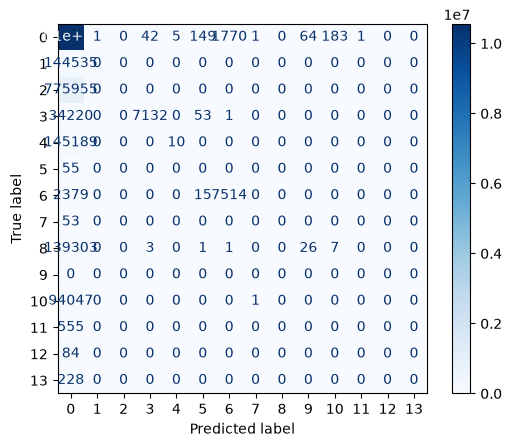

In [18]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

cm = confusion_matrix(y, rf_pred)

disp = ConfusionMatrixDisplay(cm)

disp.plot(
    cmap="Blues"
)